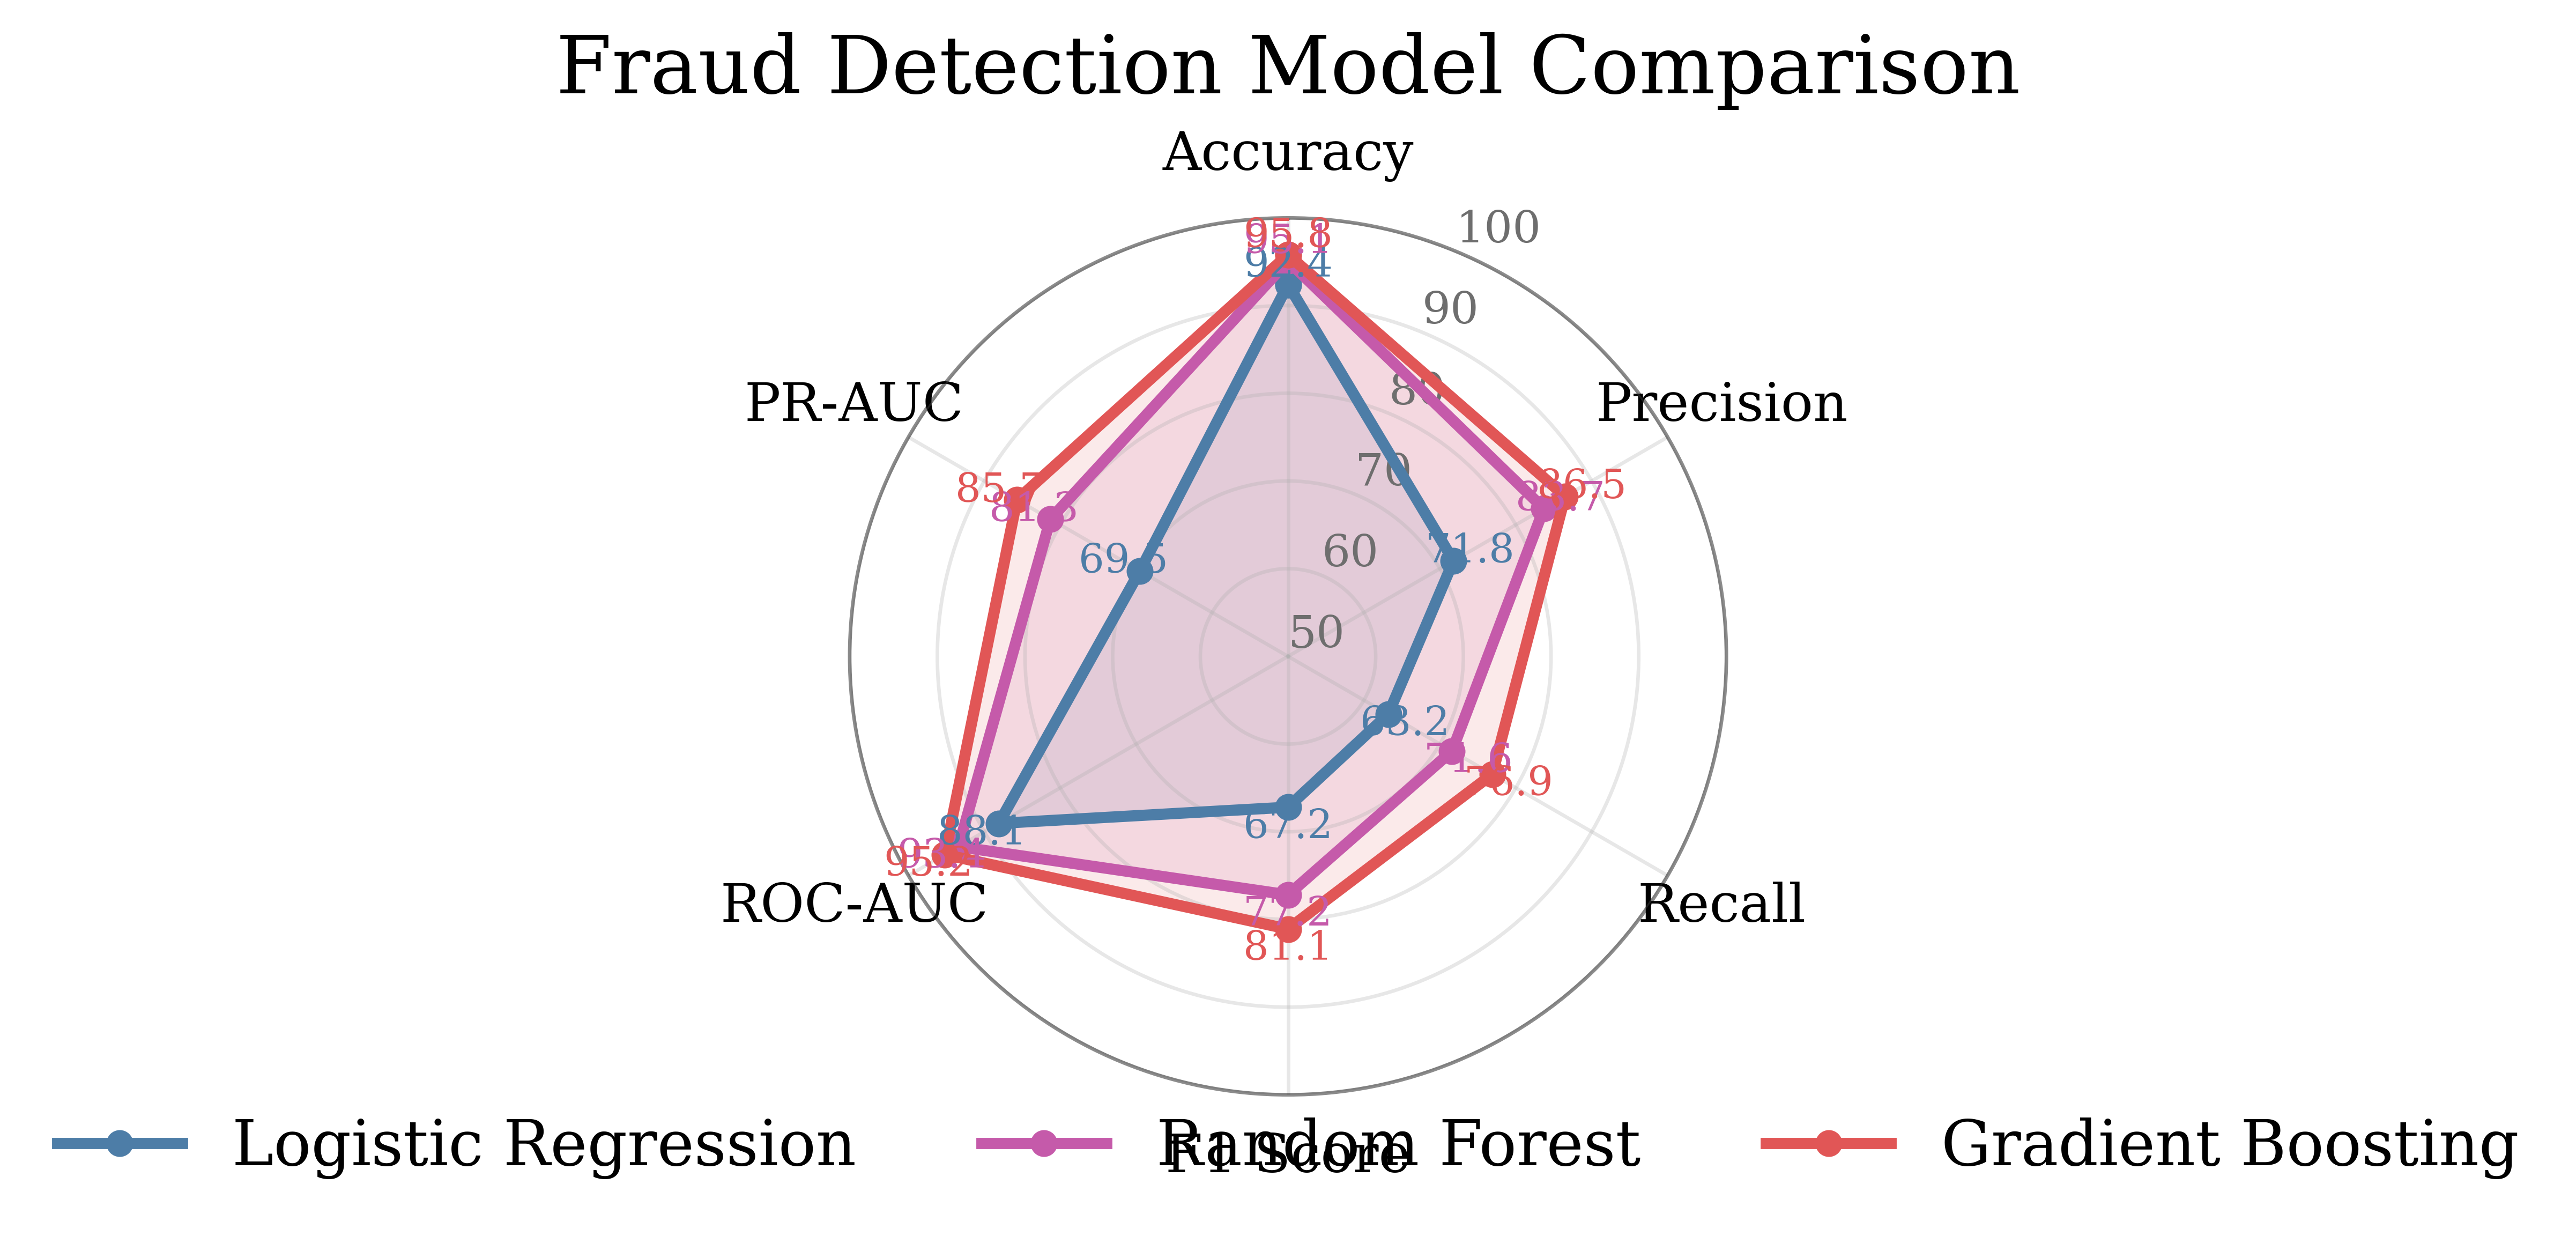

In [ ]:
"""
Radar chart/ spider plots
Radar chart comparing fraud-detection models across evaluation metrics.
"""

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Global plot configuration
# ---------------------------------------------------------------------
base_fontsize = 18

title_fontsize = base_fontsize
metric_label_fontsize = base_fontsize - 6
radial_tick_fontsize = base_fontsize - 8
annotation_fontsize = base_fontsize - 9
legend_fontsize = base_fontsize - 4

linewidth = 2.5
marker_size = 5

title_padding = 28
value_label_offset = 2.2

grid_alpha = 0.30
fill_alpha = 0.12
spine_alpha = 0.45

figure_size = (9, 9)
radial_min = 50
radial_max = 100
radial_ticks = [50, 60, 70, 80, 90, 100]


plt.rcParams["lines.linewidth"] = linewidth
plt.rcParams["axes.labelsize"] = base_fontsize
plt.rcParams["axes.titlesize"] = title_fontsize
plt.rcParams["xtick.labelsize"] = metric_label_fontsize
plt.rcParams["ytick.labelsize"] = radial_tick_fontsize
plt.rcParams["legend.fontsize"] = legend_fontsize

plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"


# ---------------------------------------------------------------------
# Custom colors
# ---------------------------------------------------------------------
niceblue = "#4d7da7"
nicered = "#e15656"
nicegreen = "#6dc350"
nicegray = "#6e6e6e"
nicemagenta = "#c55aaa"

# ---------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
]

results = {
    "Logistic Regression": [92.4, 71.8, 63.2, 67.2, 88.1, 69.5],
    "Random Forest": [95.1, 83.7, 71.6, 77.2, 93.4, 81.3],
    "Gradient Boosting": [95.8, 86.5, 76.9, 81.1, 95.2, 85.7],
}

model_colors = {
    "Logistic Regression": niceblue,
    "Random Forest": nicemagenta,
    "Gradient Boosting": nicered,
}


# ---------------------------------------------------------------------
# Radar-chart coordinates
# ---------------------------------------------------------------------
n_metrics = len(metrics)

angles = np.linspace(
    start=0,
    stop=2 * np.pi,
    num=n_metrics,
    endpoint=False,
).tolist()

angles_closed = angles + angles[:1]


# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=figure_size,
    subplot_kw={"projection": "polar"},
)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles)
ax.set_xticklabels(
    metrics,
    fontsize=metric_label_fontsize,
    fontweight="light",
)

ax.set_ylim(radial_min, radial_max)
ax.set_yticks(radial_ticks)
ax.set_yticklabels(
    [str(tick) for tick in radial_ticks],
    color=nicegray,
    fontsize=radial_tick_fontsize,
)

ax.grid(alpha=grid_alpha)
ax.spines["polar"].set_alpha(spine_alpha)


# ---------------------------------------------------------------------
# Plot models
# ---------------------------------------------------------------------
for model_name, scores in results.items():
    scores_closed = scores + scores[:1]
    color = model_colors[model_name]

    ax.plot(
        angles_closed,
        scores_closed,
        color=color,
        linewidth=linewidth,
        marker="o",
        markersize=marker_size,
        label=model_name,
    )

    ax.fill(
        angles_closed,
        scores_closed,
        color=color,
        alpha=fill_alpha,
    )

    for angle, score in zip(angles, scores):
        ax.text(
            angle,
            score + value_label_offset,
            f"{score:.1f}",
            ha="center",
            va="center",
            fontsize=annotation_fontsize,
            fontweight="light",
            color=color,
        )



ax.set_title(
    "Fraud Detection Model Comparison",
    fontsize=title_fontsize,
    fontweight="light",
    pad=title_padding,
)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=3,
    frameon=False,
    fontsize=legend_fontsize,
)


# save
# plt.tight_layout()
# plt.savefig("my_plot.pdf", bbox_inches="tight")
plt.show()